## Title: "Chapter 3 HW"
### Author: "Makenna Worley"
### Date: "9/10/2025"

In [29]:
# import packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [30]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn

### Setup

In [31]:
Auto = pd.read_csv('Auto.csv', na_values='?').dropna()
Auto_columns = Auto.columns.tolist()
print(Auto_columns)


Carseats = pd.read_csv('Carseats.csv', na_values='?').dropna()
Carseats_columns = Carseats.columns.tolist()
print(Carseats_columns)

['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'year', 'origin', 'name']
['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price', 'ShelveLoc', 'Age', 'Education', 'Urban', 'US']


#### (9a) Produce a scatterplot matrix which includes all of the variables in the data set.

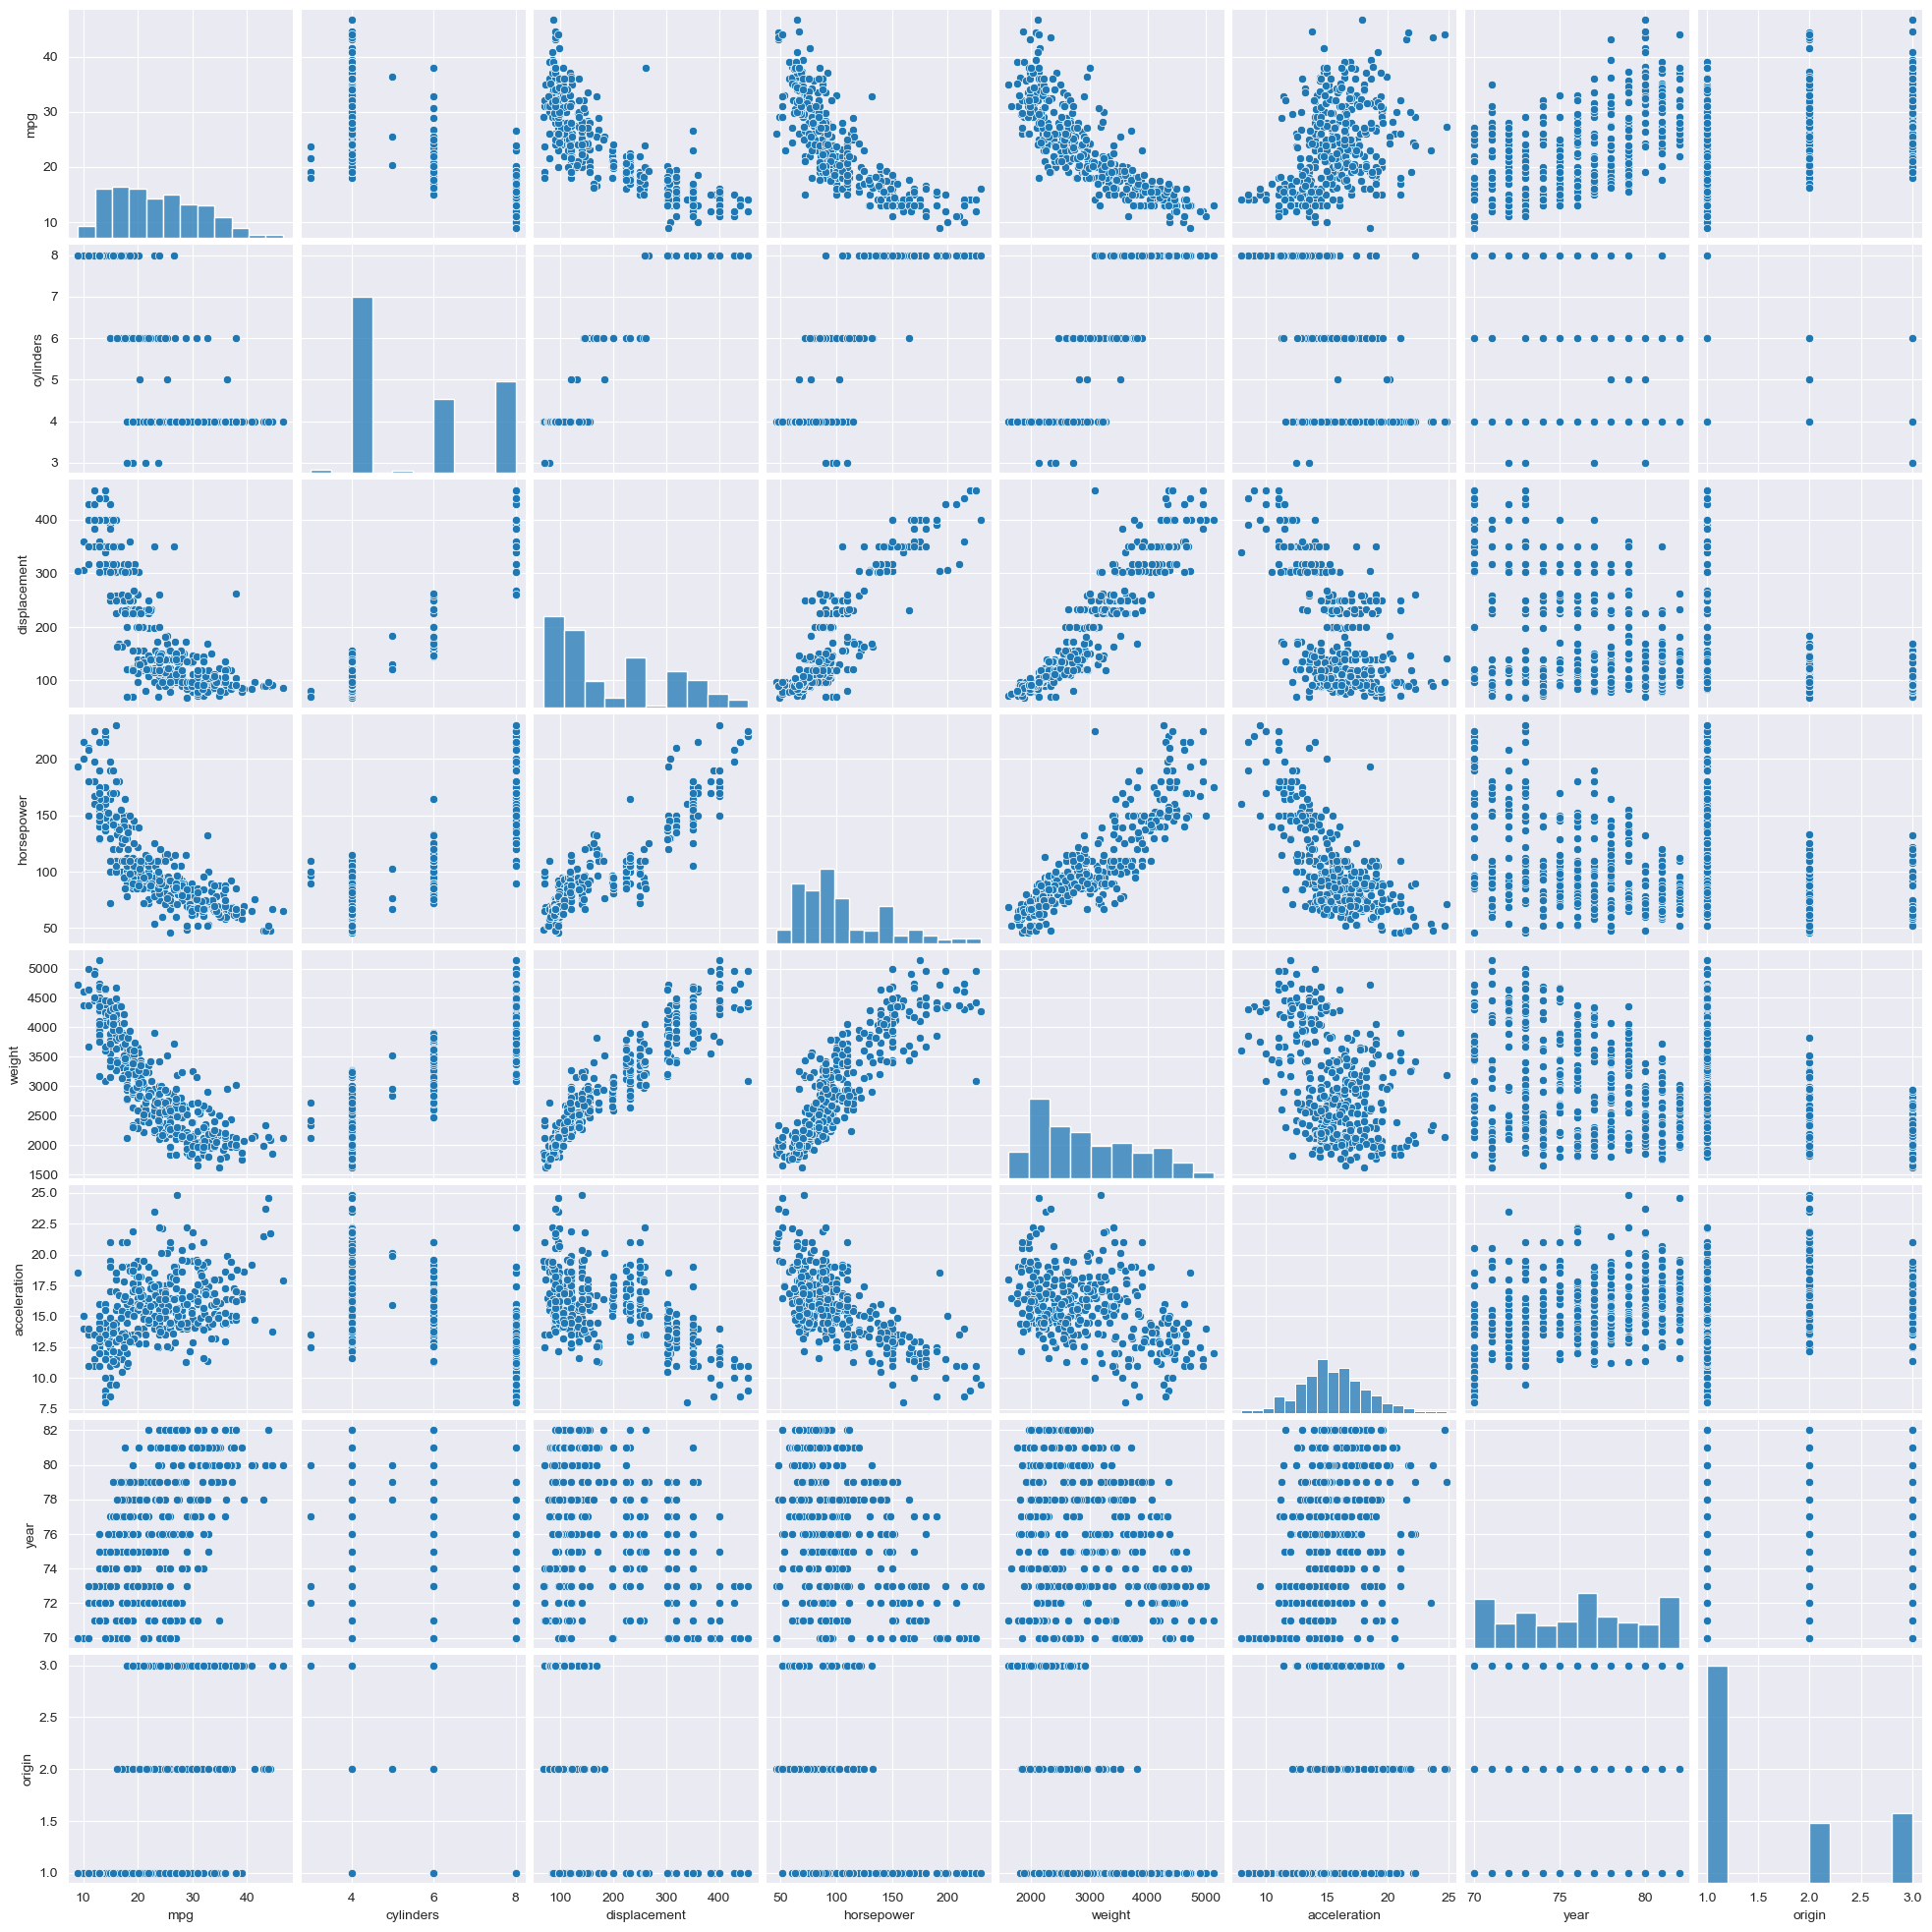

In [32]:
sns.pairplot(Auto.drop(columns="name"), diag_kind="hist")

#### (9b) Compute the matrix of correlations between the variables using the DataFrame.corr() method.

In [33]:
X = pd.DataFrame({"intercept": np.ones(len(Auto))})

for col in Auto.columns:
    if col != 'name':
        X[col] = Auto[col]

X[:4]

,intercept,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
0,1.0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0
1,1.0,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0
2,1.0,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0
3,1.0,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0


#### (9ci) Is there a relationship between the predictors and the response? Use the anova_lm() function from statsmodels to answer this question.

In [34]:
from statsmodels.stats.anova import anova_lm
from ISLP.models import summarize

model = smf.ols(
    "mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin",
    data=Auto
).fit()
summarize(model)

anova_results = anova_lm(model, typ=2)
print(anova_results)

                   sum_sq     df           F        PR(>F)
cylinders       25.791491    1.0    2.329125  1.277965e-01
displacement    77.612668    1.0    7.008884  8.444649e-03
horsepower      16.739754    1.0    1.511699  2.196328e-01
weight        1091.631693    1.0   98.580813  7.874953e-21
acceleration     7.358417    1.0    0.664509  4.154780e-01
year          2402.249906    1.0  216.937408  3.055983e-39
origin         291.134494    1.0   26.291171  4.665681e-07
Residual      4252.212530  384.0         NaN           NaN


#### (9cii) Which predictors appear to have a statistically significant relationship to the response?

In the PR(>F), we have values under 0.05 for: displacement, weight, year, origin.

#### (9ciii) What does the coefficient for the year variable suggest?

For each additional year on the car, the expected fuel economy increases by about .7-.8 mpg if we hold everything else stable.

#### (9d) Produce some of diagnostic plots of the linear regression fit as described in the lab. Comment on any problems you see with the fit. Do the residual plots suggest any unusually large outliers? Does the leverage plot identify any observations with unusually high leverage?

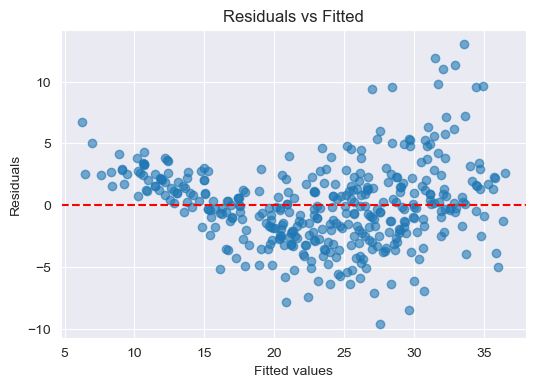

In [35]:
model = smf.ols(
    "mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin",
    data=Auto
).fit()

plt.figure(figsize=(6,4))
plt.scatter(model.fittedvalues, model.resid, alpha=0.6)
plt.axhline(0, color='red', ls='--')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted");

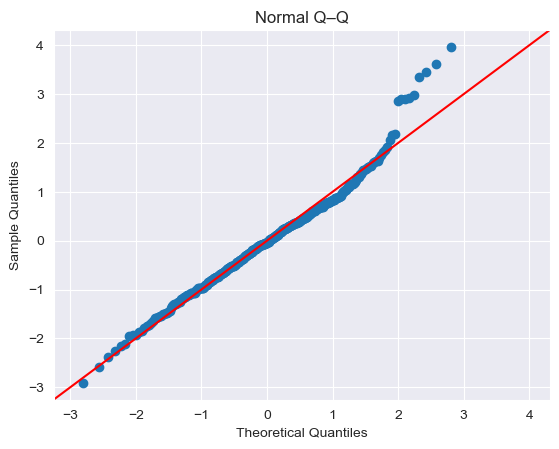

In [36]:
sm.qqplot(model.resid, line="45", fit=True)
plt.title("Normal Q–Q");

Text(0, 0.5, 'Residuals')

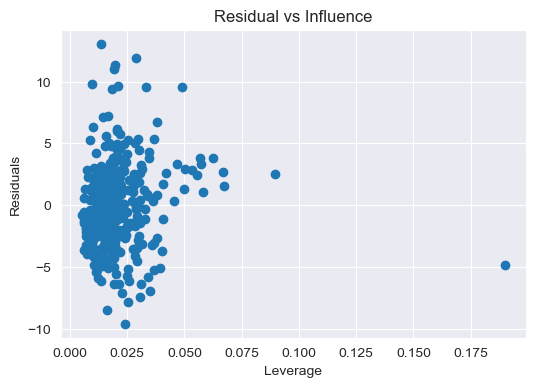

In [37]:
influence = model.get_influence()
leverage = influence.hat_matrix_diag

plt.figure(figsize=(6,4))
plt.scatter(leverage, model.resid)
plt.title("Residual vs Influence");
plt.xlabel("Leverage")
plt.ylabel("Residuals")

Residual vs Fitted: We see a parabola shape or almost funnel shape (narrower towards the lower fitted values and wider with higher values). It looks like it's not purely linear

Normal Q-Q: We see it mostly follows the line but it does bend off the line towards the higher values. So it looks like the residuals are roughly normal but there are some high positive residuals

Leverage vs Residuals: Most points are very very small but there is one that is an outlier. There's high leverage in the coefficients

#### (9e) Fit some models with interactions as described in the lab. Do any interactions appear to be statistically significant?

In [38]:
formula_int = """
mpg ~ cylinders + displacement + horsepower + weight + acceleration + year + origin
      + weight:year + cylinders:displacement + horsepower:weight
"""
model_int = smf.ols(" ".join(formula_int.split()), data=Auto).fit()
print(model_int.summary())

anova_lm(model, model_int)

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.869
Model:                            OLS   Adj. R-squared:                  0.865
Method:                 Least Squares   F-statistic:                     251.9
Date:                Mon, 15 Sep 2025   Prob (F-statistic):          3.99e-161
Time:                        12:37:20   Log-Likelihood:                -963.38
No. Observations:                 392   AIC:                             1949.
Df Residuals:                     381   BIC:                             1992.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                -54

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,384.0,4252.212530,0.0,NaN,NaN,NaN
1,381.0,3129.450158,3.0,1122.762372,45.564177,3.489236e-25


#### (9f) Try a few different transformations of the variables, such as log(X), √X, X^2. Comment on your findings.

In [39]:
Auto_tf = Auto.copy()
Auto_tf["log_weight"]       = np.log(Auto_tf["weight"])
Auto_tf["log_horsepower"]   = np.log(Auto_tf["horsepower"])
Auto_tf["sqrt_displacement"]= np.sqrt(Auto_tf["displacement"])
Auto_tf["weight2"]          = Auto_tf["weight"]**2
Auto_tf["origin_cat"]       = Auto_tf["origin"].astype("category")

formula_tf = """
mpg ~ cylinders + sqrt_displacement + log_horsepower + log_weight
      + acceleration + year + C(origin_cat) + weight2
"""
model_tf = smf.ols(" ".join(formula_tf.split()), data=Auto_tf).fit()
print(model_tf.summary())

pd.DataFrame({
    "model": ["baseline","interactions","transformed"],
    "AIC":   [model.aic, model_int.aic, model_tf.aic],
    "Adj_R2":[model.rsquared_adj, model_int.rsquared_adj, model_tf.rsquared_adj],
})

                            OLS Regression Results                            
Dep. Variable:                    mpg   R-squared:                       0.860
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     260.0
Date:                Mon, 15 Sep 2025   Prob (F-statistic):          6.38e-157
Time:                        12:37:20   Log-Likelihood:                -976.27
No. Observations:                 392   AIC:                             1973.
Df Residuals:                     382   BIC:                             2012.
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept            198.3324     17

,model,AIC,Adj_R2
0,baseline,2062.949500,0.818224
1,interactions,1948.769308,0.865167
2,transformed,1972.549728,0.856378


#### (10a) Fit a multiple regression model to predict Sales using Price, Urban, and US.

In [40]:
model = smf.ols('Sales ~ Price + C(Urban) + C(US)', data=Carseats).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Mon, 15 Sep 2025   Prob (F-statistic):           2.39e-23
Time:                        12:37:20   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          13.0435      0.651     

#### (10b) Provide an interpretation of each coefficient in the model. Be careful—some of the variables in the model are qualitative!

Intercept: The predicted sales for stores outside is 13.04 when the price is 0

Price: For every dollar increase we expect about .0545 drop in sales

UrbanYes: The urban stores sell .0219 less than non urban stores

USYes: US stores sell about 1.2 more units than non US stores

#### (10c) Write out the model in equation form, being careful to handle the qualitative variables properly.

Sales = 13.0 – 0.05*Price – 0.02*UrbanYes + 1.2*USYes

#### (10d) For which of the predictors can you reject the null hypothesis H0 : βj = 0?

When any of the p values for price, urban, or US is less than .05

We can reject because of the values of US and price

#### (10e) On the basis of your response to the previous question, fit a smaller model that only uses the predictors for which there is evidence of association with the outcome.

In [41]:
model1 = smf.ols('Sales ~ Price + C(US)', data=Carseats).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.235
Method:                 Least Squares   F-statistic:                     62.43
Date:                Mon, 15 Sep 2025   Prob (F-statistic):           2.66e-24
Time:                        12:37:20   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1861.
Df Residuals:                     397   BIC:                             1873.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept       13.0308      0.631     20.652   

#### (10f) How well do the models in (a) and (e) fit the data?

In [42]:
print(model.summary())
print(model1.summary())

print("Full model Adj R²:", model.rsquared_adj)
print("Small model Adj R²:", model1.rsquared_adj)
print("Full model AIC:", model.aic, "Small model AIC:", model1.aic)

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.239
Model:                            OLS   Adj. R-squared:                  0.234
Method:                 Least Squares   F-statistic:                     41.52
Date:                Mon, 15 Sep 2025   Prob (F-statistic):           2.39e-23
Time:                        12:37:20   Log-Likelihood:                -927.66
No. Observations:                 400   AIC:                             1863.
Df Residuals:                     396   BIC:                             1879.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept          13.0435      0.651     

Both models fit the data well, the full model (price, urban, US) is almost equivalent to the smaller model (price and US). Therefore it might be better to use the small model because it is more simple

#### (10g) Using the model from (e), obtain 95 % confidence intervals for the coefficient(s).

In [43]:
model1.conf_int(alpha=0.05)

,0,1
Intercept,11.79032,14.271265
C(US)[T.Yes],0.69152,1.707766
Price,-0.06476,-0.044195


#### (10h) Is there evidence of outliers or high leverage observations in the model from (e)?

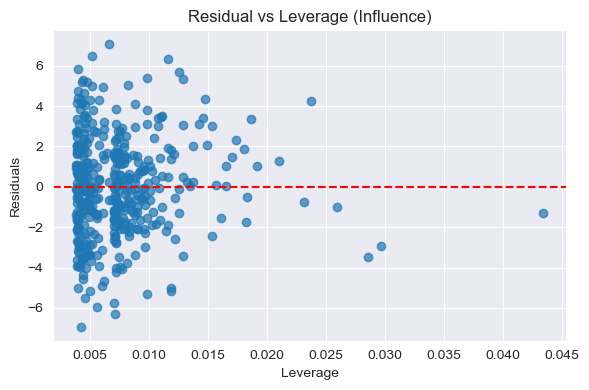

In [44]:
influence = model1.get_influence()
leverage = influence.hat_matrix_diag

plt.figure(figsize=(6,4))
plt.scatter(leverage, model1.resid, alpha=0.7)
plt.axhline(0, color="red", ls="--")
plt.title("Residual vs Leverage (Influence)")
plt.xlabel("Leverage")
plt.ylabel("Residuals")
plt.tight_layout()
plt.show()


We can see that there are a bunch of points where the leverage is much higher but there is also an outlier here too

#### (13a) Using the normal() method of your random number generator, create a vector, x, containing 100 observations drawn from a N (0, 1) distribution. This represents a feature, X.

In [45]:
np.random.seed(1)

n = 100
x = np.random.normal(loc=0, scale=1, size=n)
print(np.mean(x), np.min(x), np.max(x))

0.060582852075698704 -2.3015386968802827 2.1855754065331614


#### (13b) Using the normal() method, create a vector, eps, containing 100 observations drawn from a N (0, 0.25) distribution—a normal distribution with mean zero and variance 0.25.

In [46]:
eps = np.random.normal(loc=0, scale=np.sqrt(0.25), size=n)
print(np.mean(eps), np.min(eps), np.max(eps))

0.07639738881009925 -1.2174188820535694 1.264162853403199


#### (13c) Usingx and eps, generate a vector y according to the model Y=−1 + 0.5X + ϵ. What is the length of the vector y? What are the values of β0 and β1 in this linear model?

In [47]:
beta0_true, beta1_true = -1.0, 0.5
y = beta0_true + beta1_true * x + eps
len_y = len(y)
beta0_true, beta1_true, len_y

(-1.0, 0.5, 100)

#### (13d) Create a scatterplot displaying the relationship betweenx and y. Comment on what you observe.

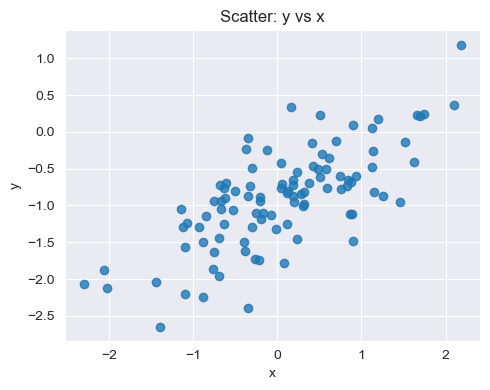

In [48]:
plt.figure(figsize=(5,4))
plt.scatter(x, y, alpha=0.8)
plt.xlabel("x"); plt.ylabel("y"); plt.title("Scatter: y vs x")
plt.tight_layout(); plt.show()

I see an upward trend looking like there is a positive linear relationship

#### (13e) Fit a least squares linear model to predict y using x. Comment on the model obtained. How do ˆβ0 and ˆβ1 compare to β0 and β1?

In [49]:
df = pd.DataFrame({"x": x, "y": y})
lin = smf.ols("y ~ x", data=df).fit()
print(lin.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.517
Method:                 Least Squares   F-statistic:                     107.0
Date:                Mon, 15 Sep 2025   Prob (F-statistic):           2.20e-17
Time:                        12:37:21   Log-Likelihood:                -65.124
No. Observations:                 100   AIC:                             134.2
Df Residuals:                      98   BIC:                             139.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9265      0.047    -19.717      0.0

I can see that B_0 is close to -1 and that B_1 is close to .5. So the line looks like y = -.994 + .479x and our R^2 value is .417

#### (13f) Display the least squares line on the scatterplot obtained in (d). Draw the population regression line on the plot, in a different color. Use the legend() method of the axes to create an appropriate legend.

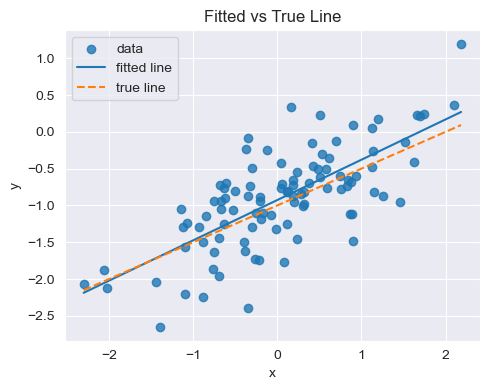

In [50]:
xs = np.linspace(x.min(), x.max(), 200)
y_fit = lin.params["Intercept"] + lin.params["x"] * xs
y_true = beta0_true + beta1_true * xs

plt.figure(figsize=(5,4))
plt.scatter(x, y, alpha=0.8, label="data")
plt.plot(xs, y_fit, label="fitted line")
plt.plot(xs, y_true, label="true line", linestyle="--")
plt.xlabel("x"); plt.ylabel("y"); plt.title("Fitted vs True Line")
plt.legend(); plt.tight_layout(); plt.show()

#### (13g) Now fit a polynomial regression model that predicts y using x and x2. Is there evidence that the quadratic term improves the model fit? Explain your answer.

In [51]:
df["x2"] = df["x"]**2
quad = smf.ols("y ~ x + x2", data=df).fit()
print(quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     52.96
Date:                Mon, 15 Sep 2025   Prob (F-statistic):           2.83e-16
Time:                        12:37:21   Log-Likelihood:                -65.107
No. Observations:                 100   AIC:                             136.2
Df Residuals:                      97   BIC:                             144.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9325      0.058    -16.158      0.0

In [52]:
print(quad.summary())
print(lin.summary())

print("Quad Adj R²:", quad.rsquared_adj)
print("Lin Adj R²:", lin.rsquared_adj)
print("Quad AIC:", quad.aic, "Lin AIC:", lin.aic)

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.522
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     52.96
Date:                Mon, 15 Sep 2025   Prob (F-statistic):           2.83e-16
Time:                        12:37:21   Log-Likelihood:                -65.107
No. Observations:                 100   AIC:                             136.2
Df Residuals:                      97   BIC:                             144.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9325      0.058    -16.158      0.0

Both models fit the data well, the quad model is almost equivalent to the linear model. Therefore it might be better to use the linear model because it is more simple

#### (13h) Repeat (a)–(f) after modifying the data generation process in such a way that there is less noise in the data. The model (3.39) should remain the same. You can do this by decreasing the variance of the normal distribution used to generate the error term ϵ in (b). Describe your results.

In [53]:
def run_once(noise_var):
    eps = np.random.normal(0, np.sqrt(noise_var), size=n)
    y = beta0_true + beta1_true * x + eps
    d = pd.DataFrame({"x": x, "y": y, "x2": x**2})
    m = smf.ols("y ~ x", data=d).fit()
    return m, d

m_less, d_less = run_once(noise_var=0.05)
print("Less-noise model (var=0.05):")
print(m_less.summary())

Less-noise model (var=0.05):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.789
Model:                            OLS   Adj. R-squared:                  0.787
Method:                 Least Squares   F-statistic:                     366.8
Date:                Mon, 15 Sep 2025   Prob (F-statistic):           6.75e-35
Time:                        12:37:21   Log-Likelihood:                 7.4658
No. Observations:                 100   AIC:                            -10.93
Df Residuals:                      98   BIC:                            -5.721
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.9972  

We see values of beta_0 being almost -1, beta_1 being almost .5, R^2 being .79. So with little noise we still are very close to the regression line

#### (13i) Repeat (a)–(f) after modifying the data generation process in such a way that there is more noise in the data. The model (3.39) should remain the same. You can do this by increasing the variance of the normal distribution used to generate the error term ϵ in (b). Describe your results.

In [54]:
m_more, d_more = run_once(noise_var=1.0)
print("More-noise model (var=1.0):")
print(m_more.summary())

More-noise model (var=1.0):
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.098
Model:                            OLS   Adj. R-squared:                  0.089
Method:                 Least Squares   F-statistic:                     10.62
Date:                Mon, 15 Sep 2025   Prob (F-statistic):            0.00154
Time:                        12:37:21   Log-Likelihood:                -147.75
No. Observations:                 100   AIC:                             299.5
Df Residuals:                      98   BIC:                             304.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -1.0140   

We see values of beta_0 being almost -1, beta_1 being almost .4, R^2 being .1. So with a lot of noise our errors are larger and our R^2 value drops

#### (13j) What are the confidence intervals for β0 and β1 based on the original data set, the noisier data set, and the less noisy data set? Comment on your results.

In [55]:
ci_orig = lin.conf_int()
ci_less = m_less.conf_int()
ci_more = m_more.conf_int()

ci_table = pd.DataFrame({
    "orig β0 CI low":  [ci_orig.loc["Intercept", 0]],
    "orig β0 CI high": [ci_orig.loc["Intercept", 1]],
    "orig β1 CI low":  [ci_orig.loc["x", 0]],
    "orig β1 CI high": [ci_orig.loc["x", 1]],
    "less β0 CI low":  [ci_less.loc["Intercept", 0]],
    "less β0 CI high": [ci_less.loc["Intercept", 1]],
    "less β1 CI low":  [ci_less.loc["x", 0]],
    "less β1 CI high": [ci_less.loc["x", 1]],
    "more β0 CI low":  [ci_more.loc["Intercept", 0]],
    "more β0 CI high": [ci_more.loc["Intercept", 1]],
    "more β1 CI low":  [ci_more.loc["x", 0]],
    "more β1 CI high": [ci_more.loc["x", 1]],
})
ci_table

,orig β0 CI low,orig β0 CI high,orig β1 CI low,orig β1 CI high,less β0 CI low,less β0 CI high,less β1 CI low,less β1 CI high,more β0 CI low,more β0 CI high,more β1 CI low,more β1 CI high
0,-1.019741,-0.833246,0.442613,0.652814,-1.042369,-0.952126,0.439962,0.541676,-1.227007,-0.800916,0.154222,0.634472


We see that the model with little noise is better than the original model which is much better than the model with a lot of noise. So the lower the error variance the smaller our standard errors and thus the narrower our confidence interval is